In [32]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
import numpy as np
from pathlib import Path

# Leer credenciales de ~/.cogni/config.json (mismo archivo que cogni-gui.py)
_CONFIG_PATH = Path.home() / ".cogni" / "config.json"
_cfg = json.loads(_CONFIG_PATH.read_text(encoding="utf-8"))
_db = _cfg["db"]

conn = psycopg2.connect(
    host=_db["host"],
    port=int(_db.get("port", 5432)),
    dbname=_db["dbname"],
    user=_db["user"],
    password=_db.get("password", ""),
)

query = """
    SELECT
    ts,
    time_elapsed,
    stimulus,
    -- S4 D12
    s4_d12_740nm_rp,
    s4_d12_740nm_lp,
    s4_d12_850nm_rp,
    s4_d12_850nm_lp,
    -- S4 D11
    s4_d11_740nm_rp,
    s4_d11_740nm_lp,
    s4_d11_850nm_rp,
    s4_d11_850nm_lp,
    -- S5 D12
    s5_d12_740nm_rp,
    s5_d12_740nm_lp,
    s5_d12_850nm_rp,
    s5_d12_850nm_lp,
    -- S5 D13
    s5_d13_740nm_rp,
    s5_d13_740nm_lp,
    s5_d13_850nm_rp,
    s5_d13_850nm_lp,
    -- S5 D15
    s5_d15_740nm_rp,
    s5_d15_740nm_lp,
    s5_d15_850nm_rp,
    s5_d15_850nm_lp,
    -- S1 D11
    s1_d11_740nm_rp,
    s1_d11_740nm_lp,
    s1_d11_850nm_rp,
    s1_d11_850nm_lp,
    -- S1 D9
    s1_d9_740nm_rp,
    s1_d9_740nm_lp,
    s1_d9_850nm_rp,
    s1_d9_850nm_lp,
    -- S3 D12
    s3_d12_740nm_rp,
    s3_d12_740nm_lp,
    s3_d12_850nm_rp,
    s3_d12_850nm_lp,
    -- S3 D11
    s3_d11_740nm_rp,
    s3_d11_740nm_lp,
    s3_d11_850nm_rp,
    s3_d11_850nm_lp,
    -- S3 D10
    s3_d10_740nm_rp,
    s3_d10_740nm_lp,
    s3_d10_850nm_rp,
    s3_d10_850nm_lp,
    -- S3 D15
    s3_d15_740nm_rp,
    s3_d15_740nm_lp,
    s3_d15_850nm_rp,
    s3_d15_850nm_lp,
    -- S7 D13
    s7_d13_740nm_rp,
    s7_d13_740nm_lp,
    s7_d13_850nm_rp,
    s7_d13_850nm_lp,
    -- S7 D15
    s7_d15_740nm_rp,
    s7_d15_740nm_lp,
    s7_d15_850nm_rp,
    s7_d15_850nm_lp,
    -- S7 D16
    s7_d16_740nm_rp,
    s7_d16_740nm_lp,
    s7_d16_850nm_rp,
    s7_d16_850nm_lp,
    -- S7 D14
    s7_d14_740nm_rp,
    s7_d14_740nm_lp,
    s7_d14_850nm_rp,
    s7_d14_850nm_lp,
    -- S2 D9
    s2_d9_740nm_rp,
    s2_d9_740nm_lp,
    s2_d9_850nm_rp,
    s2_d9_850nm_lp,
    -- S2 D11
    s2_d11_740nm_rp,
    s2_d11_740nm_lp,
    s2_d11_850nm_rp,
    s2_d11_850nm_lp,
    -- S2 D10
    s2_d10_740nm_rp,
    s2_d10_740nm_lp,
    s2_d10_850nm_rp,
    s2_d10_850nm_lp,
    -- S6 D10
    s6_d10_740nm_rp,
    s6_d10_740nm_lp,
    s6_d10_850nm_rp,
    s6_d10_850nm_lp,
    -- S6 D15
    s6_d15_740nm_rp,
    s6_d15_740nm_lp,
    s6_d15_850nm_rp,
    s6_d15_850nm_lp,
    -- S6 D14
    s6_d14_740nm_rp,
    s6_d14_740nm_lp,
    s6_d14_850nm_rp,
    s6_d14_850nm_lp,
    -- S8 D16
    s8_d16_740nm_rp,
    s8_d16_740nm_lp,
    s8_d16_850nm_rp,
    s8_d16_850nm_lp,
    -- S8 D14
    s8_d14_740nm_rp,
    s8_d14_740nm_lp,
    s8_d14_850nm_rp,
    s8_d14_850nm_lp
    FROM frames
    WHERE 
        session_id = 'bbb7e4c5-46cd-42f5-8e66-1e303f30a01a'
    ORDER BY time_elapsed ASC
"""

raw_data = pd.read_sql(query, conn)


/var/folders/31/xwhnlymx3311fjz1p3vjrp1h0000gn/T/ipykernel_71526/2255901735.py:147: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw_data = pd.read_sql(query, conn)


In [29]:
# Segment data by stimulus transitions
# Each contiguous block of same stimulus value gets a unique segment_id
raw_data['segment_id'] = (raw_data['stimulus'] != raw_data['stimulus'].shift()).cumsum()

# Split into baseline (stimulus=0) and active (stimulus=1)
df_baseline = raw_data[raw_data['stimulus'] == 0].copy()
df_active   = raw_data[raw_data['stimulus'] == 1].copy()

# List of individual baseline segments (useful for per-segment I0 calculation)
baseline_segments = [seg for _, seg in df_baseline.groupby('segment_id')]
active_segments   = [seg for _, seg in df_active.groupby('segment_id')]

print(f"Total segments: {raw_data['segment_id'].max()}")
print(f"Baseline segments (stimulus=0): {len(baseline_segments)}")
print(f"Active segments  (stimulus=1): {len(active_segments)}")

# Preview segment boundaries
segment_summary = raw_data.groupby('segment_id').agg(
    stimulus=('stimulus', 'first'),
    t_start=('time_elapsed', 'min'),
    t_end=('time_elapsed', 'max'),
    n_samples=('time_elapsed', 'count')
).reset_index()
print(segment_summary.to_string(index=False))



Total segments: 5
Baseline segments (stimulus=0): 3
Active segments  (stimulus=1): 2
 segment_id  stimulus    t_start      t_end  n_samples
          1         0   0.445521  23.035076        103
          2         1  23.245538  98.426816        340
          3         0  98.667204 141.118383        193
          4         1 141.356875 178.589893        168
          5         0 178.798209 189.900013         51


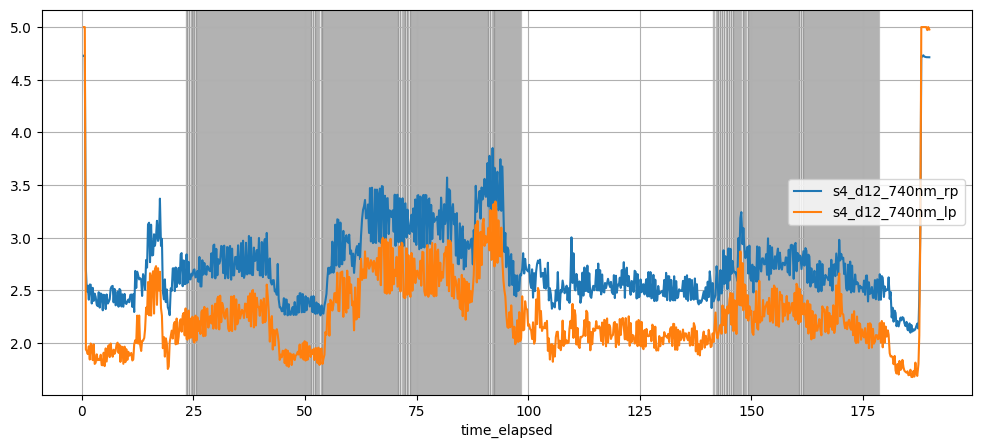

In [31]:
# create plot of x = ts and y = s4_d12_740nm_rp where background is gray of values where stimulus is 1 and 0 to white
# data_limited = raw_data[raw_data['s4_d12_740nm_rp'] <= 4]
data_limited = raw_data
data_limited.plot(x='time_elapsed', y=['s4_d12_740nm_rp','s4_d12_740nm_lp'], figsize=(12, 5), grid=True)

for i, row in data_limited.iterrows():
    if row['stimulus'] == 1:
        plt.axvspan(row['time_elapsed'], row['time_elapsed'], color='gray', alpha=0.5)
    else:
        plt.axvspan(row['time_elapsed'], row['time_elapsed'], color='white', alpha=0.5)


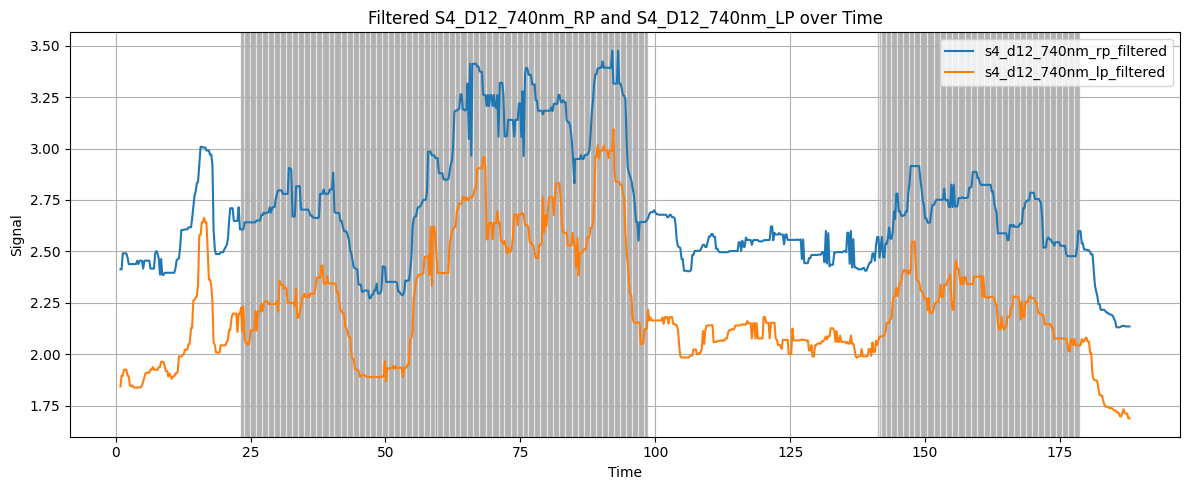

In [8]:
from scipy.signal import medfilt
# apply median filter to s4_d12_740nm_rp and s4_d12_740nm_lp column and plot it with x = ts
filtered_rp = medfilt(data_limited['s4_d12_740nm_rp'], kernel_size=11)
filtered_lp = medfilt(data_limited['s4_d12_740nm_lp'], kernel_size=11)

filtered_df = pd.DataFrame(
    {
        'time_elapsed': data_limited['time_elapsed'], 
        's4_d12_740nm_rp_filtered': filtered_rp, 
        's4_d12_740nm_lp_filtered': filtered_lp, 
        'stimulus': data_limited['stimulus'],
        'segment_id': data_limited['segment_id']
     })

filtered_df.plot(x='time_elapsed', y=['s4_d12_740nm_rp_filtered','s4_d12_740nm_lp_filtered'], figsize=(12, 5), grid=True)
plt.title('Filtered S4_D12_740nm_RP and S4_D12_740nm_LP over Time')
plt.xlabel('Time')
plt.ylabel('Signal')
plt.tight_layout()

for i, row in data_limited.iterrows():
    if row['stimulus'] == 1:
        plt.axvspan(row['time_elapsed'], row['time_elapsed'], color='gray', alpha=0.5)
    else:
        plt.axvspan(row['time_elapsed'], row['time_elapsed'], color='white', alpha=0.5)

plt.show()

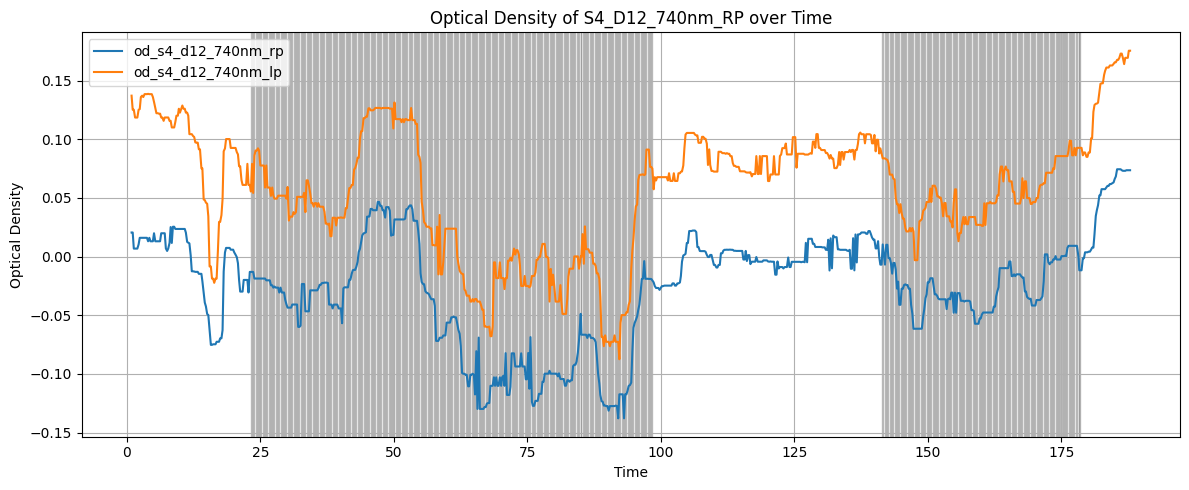

In [13]:
# Optical density

mu_rp = np.mean(filtered_df['s4_d12_740nm_rp_filtered'].where(filtered_df['segment_id'] == 3))
od_rp = -np.log10(filtered_df['s4_d12_740nm_rp_filtered'] / mu_rp)
od_lp = -np.log10(filtered_df['s4_d12_740nm_lp_filtered'] / mu_rp)

od_df = pd.DataFrame({
    'time_elapsed': filtered_df['time_elapsed'],
    'od_s4_d12_740nm_rp': od_rp,
    'od_s4_d12_740nm_lp': od_lp,
    'stimulus': filtered_df['stimulus'],
    'segment_id': filtered_df['segment_id']
})

od_df.plot(x='time_elapsed', y=['od_s4_d12_740nm_rp', 'od_s4_d12_740nm_lp'], figsize=(12, 5), grid=True)
plt.title('Optical Density of S4_D12_740nm_RP over Time')
plt.xlabel('Time')
plt.ylabel('Optical Density')
plt.tight_layout()

for i, row in data_limited.iterrows():
    if row['stimulus'] == 1:
        plt.axvspan(row['time_elapsed'], row['time_elapsed'], color='gray', alpha=0.5)
    else:
        plt.axvspan(row['time_elapsed'], row['time_elapsed'], color='white', alpha=0.5)

plt.show()